In [ ]:
!pip install pyspark


In [ ]:
from pyspark.sql import SparkSession
from pyspark.sql.types import StructType, StructField, StringType, DoubleType, IntegerType
from pyspark.sql.functions import col, year, hour, when, count, desc, to_timestamp

# Creating Spark session
spark = SparkSession.builder \
    .appName("ChicagoCrimeAnalysis") \
    .getOrCreate()

print("Spark session created!")
print("Spark version:", spark.version)


Spark session created!
Spark version: 4.0.2


In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
# Defining the schema for Chicago crime dataset
crime_schema = StructType([
    StructField("ID", StringType(), True),
    StructField("Case Number", StringType(), True),
    StructField("Date", StringType(), True),
    StructField("Block", StringType(), True),
    StructField("IUCR", StringType(), True),
    StructField("Primary Type", StringType(), True),
    StructField("Description", StringType(), True),
    StructField("Location Description", StringType(), True),
    StructField("Arrest", StringType(), True),
    StructField("Domestic", StringType(), True),
    StructField("Beat", StringType(), True),
    StructField("District", StringType(), True),
    StructField("Ward", StringType(), True),
    StructField("Community Area", StringType(), True),
    StructField("FBI Code", StringType(), True),
    StructField("X Coordinate", DoubleType(), True),
    StructField("Y Coordinate", DoubleType(), True),
    StructField("Year", IntegerType(), True),
    StructField("Updated On", StringType(), True),
    StructField("Latitude", DoubleType(), True),
    StructField("Longitude", DoubleType(), True),
    StructField("Location", StringType(), True)
])
#loading the dataset
file_path = "/content/drive/MyDrive/Crimes_-_2001_to_Present_20260324.csv"

df = spark.read.csv(file_path, header=True, schema=crime_schema)
print(" Data loaded successfully!")
print("Number of rows:", df.count())
df.show(5)


 Data loaded successfully!
Number of rows: 232871
+--------+-----------+--------------------+-------------------+----+--------------------+--------------------+--------------------+------+--------+----+--------+----+--------------+--------+------------+------------+----+--------------------+------------+-------------+--------------------+
|      ID|Case Number|                Date|              Block|IUCR|        Primary Type|         Description|Location Description|Arrest|Domestic|Beat|District|Ward|Community Area|FBI Code|X Coordinate|Y Coordinate|Year|          Updated On|    Latitude|    Longitude|            Location|
+--------+-----------+--------------------+-------------------+----+--------------------+--------------------+--------------------+------+--------+----+--------+----+--------------+--------+------------+------------+----+--------------------+------------+-------------+--------------------+
|14143467|   JK189374|03/16/2026 12:00:...|006XX S LA SALLE ST|1320|     CRIM

In [ ]:
# Remove the rows with null values
df = df.na.drop()

# Converting Date column to timestamp format
df = df.withColumn("Date", to_timestamp(col("Date"), "MM/dd/yyyy hh:mm:ss a"))

# Keep only last 10 years
df = df.filter(col("Year") >= 2015)

# Removing specific unwanted crime types
unwanted = [
    "NON-CRIMINAL (SUBJECT SPECIFIED)",
    "OTHER OFFENSE",
    "STALKING",
    "NON - CRIMINAL",
    "ARSON"
]
df = df.filter(~col("Primary Type").isin(unwanted))

# Merge the similar crime categories
df = df.withColumn(
    "Primary Type",
    when(col("Primary Type").isin("SEX OFFENSE", "PROSTITUTION"), "SEX RELATED CRIME")
    .otherwise(col("Primary Type"))
)

print(" Data cleaned — total rows after cleaning:", df.count())


 Data cleaned — total rows after cleaning: 214733


In [ ]:
#showing year-wise trend of the crime for last ten years.
crime_by_year = df.groupBy("Year").count().orderBy("Year")
crime_by_year.show()


+----+------+
|Year| count|
+----+------+
|2025|176782|
|2026| 37951|
+----+------+



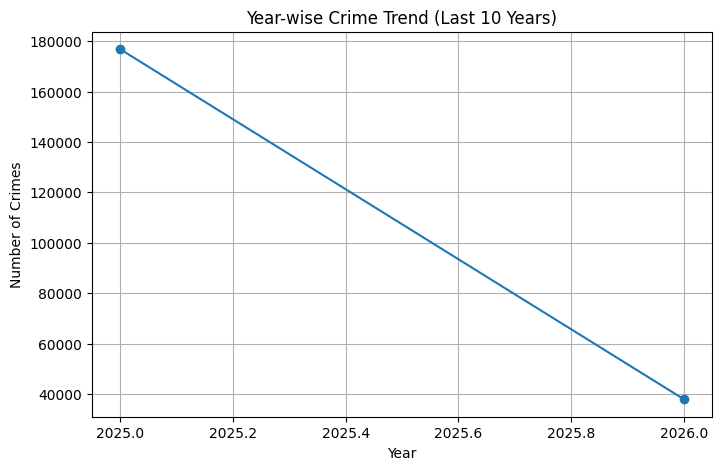

In [ ]:
import matplotlib.pyplot as plt
year_pd = crime_by_year.toPandas()
plt.figure(figsize=(8,5))
plt.plot(year_pd["Year"], year_pd["count"], marker="o")
plt.title("Year-wise Crime Trend (Last 10 Years)")
plt.xlabel("Year")
plt.ylabel("Number of Crimes")
plt.grid(True)
plt.show()


In [ ]:
#Finding out at which hour of the day crime is highest.
crime_by_hour = df.withColumn("Hour", hour(col("Date"))) \
                  .groupBy("Hour").count().orderBy(desc("count"))
crime_by_hour.show(5)


+----+-----+
|Hour|count|
+----+-----+
|   0|14121|
|  12|11899|
|  15|11705|
|  16|11589|
|  17|11488|
+----+-----+
only showing top 5 rows


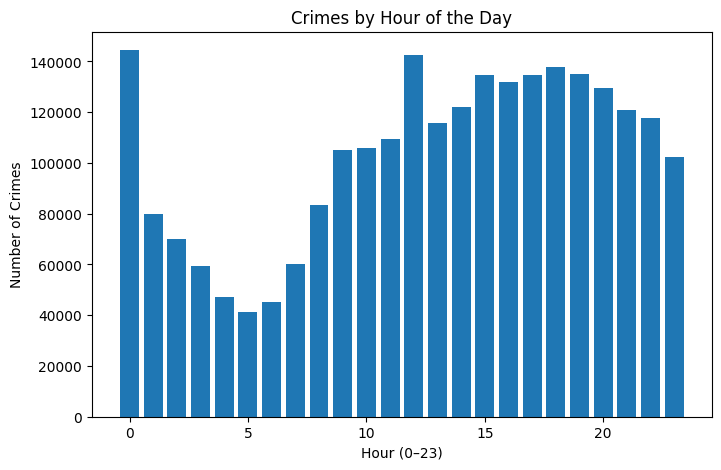

In [ ]:
hour_pd = crime_by_hour.toPandas()
plt.figure(figsize=(8,5))
plt.bar(hour_pd["Hour"], hour_pd["count"])
plt.title("Crimes by Hour of the Day")
plt.xlabel("Hour (0–23)")
plt.ylabel("Number of Crimes")
plt.show()


In [ ]:
top10 = df.groupBy("Primary Type") \
          .agg(count("*").alias("Total")) \
          .orderBy(desc("Total")) \
          .limit(10)
top10.show()


+-------------------+-----+
|       Primary Type|Total|
+-------------------+-----+
|              THEFT|53541|
|            BATTERY|42471|
|    CRIMINAL DAMAGE|26280|
|            ASSAULT|21282|
|MOTOR VEHICLE THEFT|17423|
| DECEPTIVE PRACTICE|12754|
|           BURGLARY|10225|
|          NARCOTICS| 6881|
|            ROBBERY| 5524|
|  CRIMINAL TRESPASS| 5364|
+-------------------+-----+



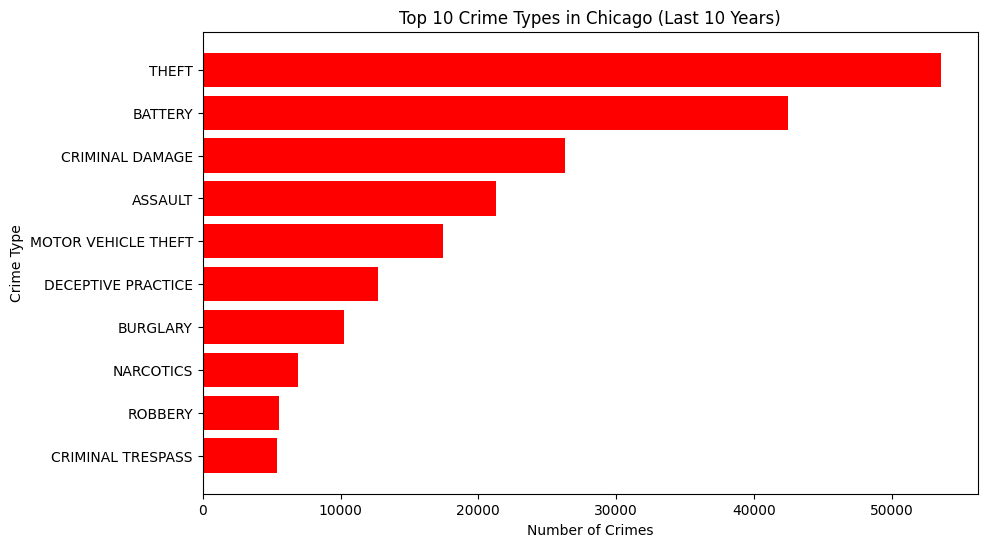

In [ ]:
#finding top ten crimes and present them as a bar chart.
top10_pd = top10.toPandas()
plt.figure(figsize=(10,6))
plt.barh(top10_pd["Primary Type"], top10_pd["Total"], color="red")
plt.gca().invert_yaxis()
plt.title("Top 10 Crime Types in Chicago (Last 10 Years)")
plt.xlabel("Number of Crimes")
plt.ylabel("Crime Type")
plt.show()
